<a href="https://colab.research.google.com/github/UshaSree13/Blog-website/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import torch
import time
from torch.cuda.amp import autocast

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = torch.nn.Sequential(
    torch.nn.Conv2d(3, 16, 3, padding=1),
    torch.nn.ReLU(),
    torch.nn.Conv2d(16, 3, 3, padding=1)
).to(device)
model.eval()

input_tensor = torch.randn(1, 3, 512, 512).to(device)

def run_inference(model, input_tensor):
    with torch.no_grad():
        torch.cuda.synchronize()
        start = time.time()
        output = model(input_tensor)
        torch.cuda.synchronize()
        end = time.time()
    return output, end - start

def run_optimized_inference(model, input_tensor):
    with torch.no_grad():
        torch.cuda.synchronize()
        start = time.time()
        with autocast():
            output = model(input_tensor.half())
        torch.cuda.synchronize()
        end = time.time()
    return output.float(), end - start

output, orig_time = run_inference(model, input_tensor)
output_opt, opt_time = run_optimized_inference(model, input_tensor)

print(f"Original Time: {orig_time:.4f}s")
print(f"Optimized Time: {opt_time:.4f}s")


Original Time: 0.0022s
Optimized Time: 0.0016s


<ipython-input-20-4515e94d64ee>:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


In [21]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_model():

    model = torch.nn.Sequential(
        torch.nn.Conv2d(3, 16, 3, padding=1),
        torch.nn.ReLU(),
        torch.nn.Conv2d(16, 3, 3, padding=1)
    )
    model.eval()
    return model.to(device)


In [22]:
model_opt = load_model().half().to(device)
model_opt.eval()


Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(16, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [23]:
model_opt = load_model().half().to(device)
model_opt.eval()
output_opt, time_opt = run_optimized_inference(model_opt, input_tensor)
mem_opt = torch.cuda.max_memory_allocated(device) / 1024**2  # MB
print(f"Optimized Inference Time: {time_opt:.4f} sec")
print(f"Optimized GPU Memory Usage: {mem_opt:.2f} MB")


Optimized Inference Time: 0.0014 sec
Optimized GPU Memory Usage: 55.52 MB


<ipython-input-20-4515e94d64ee>:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


In [24]:
from torch import amp

with amp.autocast(device_type='cuda'):
    output = model(input_tensor.half())


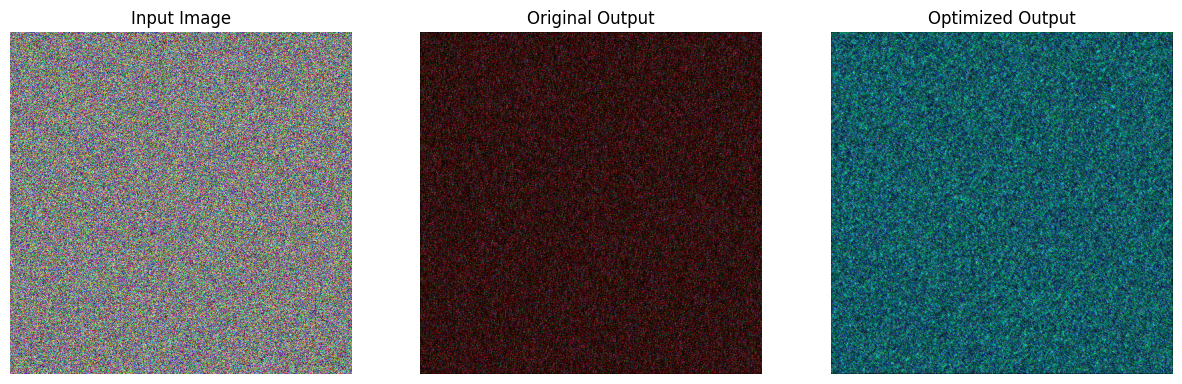

In [25]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF


def tensor_to_img(tensor):
    img = tensor.squeeze(0).cpu().clamp(0,1)
    img = TF.to_pil_image(img)
    return img


img_orig = tensor_to_img(output_orig)


img_opt = tensor_to_img(output_opt)

input_img = TF.to_pil_image(input_tensor.squeeze(0).cpu())

fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(input_img)
axs[0].set_title('Input Image')
axs[0].axis('off')

axs[1].imshow(img_orig)
axs[1].set_title('Original Output')
axs[1].axis('off')

axs[2].imshow(img_opt)
axs[2].set_title('Optimized Output')
axs[2].axis('off')

plt.show()
